In [1]:
!pip install transformers torch pandas scikit-learn matplotlib tqdm gdown

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import spacy
import gdown
from transformers import AutoModel, AutoTokenizer, AutoConfig, DefaultDataCollator
from datasets import Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef
)
import matplotlib.pyplot as plt

nlp = spacy.load("en_core_web_sm")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
url = 'https://drive.google.com/drive/folders/1GZjxZhAQlmt_gHUcXogkVgeAWWNPcOqL?usp=sharing'
gdown.download_folder(url, quiet=True, use_cookies=False)

['/content/nli_ensemble_model/deberta/moe_weights.pt',
 '/content/nli_ensemble_model/deberta/tokenizer_config.json',
 '/content/nli_ensemble_model/deberta/tokenizer.json',
 '/content/nli_ensemble_model/modernbert/moe_weights.pt',
 '/content/nli_ensemble_model/modernbert/tokenizer_config.json',
 '/content/nli_ensemble_model/modernbert/tokenizer.json']

In [4]:
class POSSpecializedMoE(nn.Module):
    def __init__(self, modelName, labelCount=2):
        # Load the baseline model
        super().__init__()
        self.encoder = AutoModel.from_pretrained(modelName).float()
        modelWidth = self.encoder.config.hidden_size
        num_logic_features = 4

        # Create experts which focus on different parts of the sentence
        self.semantic_expert = nn.Linear(modelWidth, modelWidth)
        self.entity_expert = nn.Linear(modelWidth, modelWidth)
        self.action_expert = nn.Linear(modelWidth, modelWidth)
        self.logic_expert = nn.Linear(num_logic_features, modelWidth)

        # Combines the results from the experts using a gating mechanism
        self.normalisationLayer = nn.LayerNorm(num_logic_features)
        self.gating = nn.Sequential(
            nn.Linear(modelWidth * 3 + num_logic_features, 128),
            nn.ReLU(),
            nn.Linear(128, 4),
            nn.Softmax(dim=-1)
        )

        self.classifier = nn.Linear(modelWidth, labelCount)
        self.lossFunc = nn.CrossEntropyLoss()

    # Encodes the input and extracts the [CLS] token representation
    def encode_cls(self, input_ids, attention_mask):
      outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
      cls_output = outputs.last_hidden_state[:, 0, :]
      return cls_output

    def forward(
        self,
        input_ids,
        attention_mask,
        entity_input_ids,
        entity_attention_mask,
        action_input_ids,
        action_attention_mask,
        logic_features=None,
        labels=None
    ):
        # Encode the main input, entity-focused input, and action-focused input
        main_cls = self.encode_cls(input_ids, attention_mask)
        entity_cls = self.encode_cls(entity_input_ids, entity_attention_mask)
        action_cls = self.encode_cls(action_input_ids, action_attention_mask)

        # If logic features are not provided, create a zero tensor
        if logic_features is None:
            logic_features = torch.zeros((input_ids.size(0), 4), device=input_ids.device)

        # Normalize logic features and pass through the logic expert
        logic_features = logic_features.float()
        norm_logic = self.normalisationLayer(logic_features)


        # Pass the CLS representations through their respective experts
        semanticRes = torch.tanh(self.semantic_expert(main_cls))
        entityRes = torch.tanh(self.entity_expert(entity_cls))
        actionRes = torch.tanh(self.action_expert(action_cls))
        logicRes = torch.tanh(self.logic_expert(norm_logic))


        # Use the gating mechanism to determine how much to rely on each expert
        gate_input = torch.cat([main_cls, entity_cls, action_cls, norm_logic], dim=-1)
        gate_weights = self.gating(gate_input)

        # Combine the expert outputs according to the gate weights
        experts = torch.stack([semanticRes, entityRes, actionRes, logicRes], dim=1)
        moe_output = torch.bmm(gate_weights.unsqueeze(1), experts).squeeze(1)

        logits = self.classifier(moe_output)

        loss = None
        if labels is not None:
            loss = self.lossFunc(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}




In [5]:
# Extract words based on a specific POS
def get_pos_filtered_text(text, pos_tags):
    # Generate POS tags
    doc = nlp(str(text))
    # Only select those which have been specified
    tokens = [token.text for token in doc if token.pos_ in pos_tags]
    return " ".join(tokens) if tokens else "none"

def extract_logic_features(premise, hypothesis):
    # Produce POS tags for both the premise and hypothesis
    p_doc, h_doc = nlp(str(premise)), nlp(str(hypothesis))
    # Count how many negations we see between the 2 sentences - a mismatch indicates contradiction
    neg_p = sum(1 for t in p_doc if t.dep_ == "neg")
    neg_h = sum(1 for t in h_doc if t.dep_ == "neg")
    # Removes punctuation and stopwords
    p_set = {t.lemma_.lower() for t in p_doc if not t.is_stop and not t.is_punct}
    h_set = {t.lemma_.lower() for t in h_doc if not t.is_stop and not t.is_punct}
    # Determines the overlap between sentences using Jaccard Similarity
    overlap = len(p_set & h_set) / len(p_set | h_set) if (p_set | h_set) else 0.0
    return [float(neg_p), float(neg_h), float(abs(neg_p - neg_h)), float(overlap)]


# Factory to handle HuggingFace map function
def make_preprocess_fn(tokenizer):
    def preprocess(example):
        main_enc = tokenizer(example["premise"], example["hypothesis"], truncation=True, padding="max_length", max_length=128)

        # Extract the relevant sentences for each expert
        p_nouns = get_pos_filtered_text(example["premise"], ["NOUN", "PROPN"])
        h_nouns = get_pos_filtered_text(example["hypothesis"], ["NOUN", "PROPN"])
        p_verbs = get_pos_filtered_text(example["premise"], ["VERB"])
        h_verbs = get_pos_filtered_text(example["hypothesis"], ["VERB"])

        # Encoders for the 2 experts
        ent_enc = tokenizer(p_nouns, h_nouns, truncation=True, padding="max_length", max_length=128)
        act_enc = tokenizer(p_verbs, h_verbs, truncation=True, padding="max_length", max_length=128)

        # Returns the sentences which each expert relies on
        return {
            "input_ids": main_enc["input_ids"],
            "attention_mask": main_enc["attention_mask"],

            "entity_input_ids": ent_enc["input_ids"],
            "entity_attention_mask": ent_enc["attention_mask"],

            "action_input_ids": act_enc["input_ids"],
            "action_attention_mask": act_enc["attention_mask"],

            "logic_features": [float(x) for x in extract_logic_features(example["premise"], example["hypothesis"])],

            # "labels": int(example["label"])
        }
    return preprocess


In [ ]:
def evaluate(model, tokenizer, file_path):
    print(f"\nLoading data from: {file_path}")

    df = pd.read_csv(file_path)

    premises = df["premise"].tolist()
    hypotheses = df["hypothesis"].tolist()
    labels = df["label"].tolist()

    print(f"Loaded {len(df)} samples")

    preprocess_fn = make_preprocess_fn(tokenizer)

    dataset = Dataset.from_pandas(df)
    dataset = dataset.map(preprocess_fn)

    preds = []

    model.eval()
    model.to(device)

    for example in tqdm(dataset):

        inputs = {
            "input_ids": torch.tensor(example["input_ids"]).unsqueeze(0).to(device),
            "attention_mask": torch.tensor(example["attention_mask"]).unsqueeze(0).to(device),

            "entity_input_ids": torch.tensor(example["entity_input_ids"]).unsqueeze(0).to(device),
            "entity_attention_mask": torch.tensor(example["entity_attention_mask"]).unsqueeze(0).to(device),

            "action_input_ids": torch.tensor(example["action_input_ids"]).unsqueeze(0).to(device),
            "action_attention_mask": torch.tensor(example["action_attention_mask"]).unsqueeze(0).to(device),

            "logic_features": torch.tensor(example["logic_features"]).unsqueeze(0).to(device),
        }

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs["logits"]

        pred = torch.argmax(logits, dim=1).item()
        preds.append(pred)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    print("\n=== Evaluation Metrics ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    cm = confusion_matrix(labels, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title("Confusion Matrix")
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "predictions": preds
    }


Evaluating on: dev_data/NLI/dev.csv
Loading model: deberta


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/6736 [00:00<?, ? examples/s]

Loading model: modernbert


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/6736 [00:00<?, ? examples/s]


=== Evaluation Metrics ===
Accuracy : 0.8953
Precision: 0.8936
Recall   : 0.9051
F1-score : 0.8993
MCC      : 0.7904


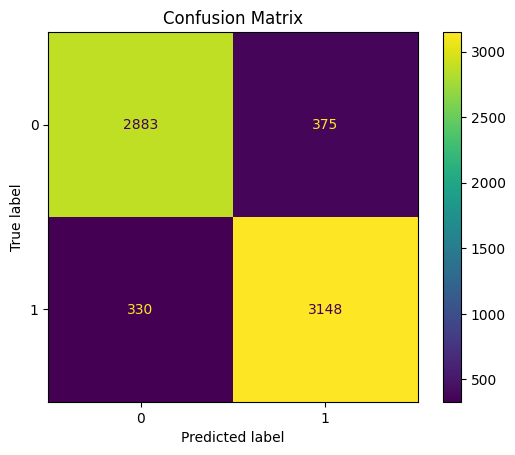

{'accuracy': 0.8953384798099763,
 'precision': 0.893556627873971,
 'recall': 0.9051178838412881,
 'f1': 0.8993000999857164,
 'mcc': np.float64(0.7904326268633772)}

In [ ]:
def evaluate(input_csv_path):
    print(f"Evaluating on: {input_csv_path}")

    ensemble_path = "nli_ensemble_model"
    backbones = {
        "deberta": "microsoft/deberta-v3-small",
        "modernbert": "answerdotai/ModernBERT-base"
    }

    df = pd.read_csv(input_csv_path)
    labels = df["label"].values

    all_model_logits = []

    for name, path in backbones.items():
        specific_dir = os.path.join(ensemble_path, name)

        tokenizer = AutoTokenizer.from_pretrained(specific_dir)
        model = POSSpecializedMoE(path)
        model.load_state_dict(torch.load(os.path.join(specific_dir, "moe_weights.pt"), map_location=device))
        model.to(device).eval()

        prep_fn = make_preprocess_fn(tokenizer)
        ds = Dataset.from_pandas(df).map(prep_fn)

        loader = torch.utils.data.DataLoader(
            ds,
            batch_size=16,
            collate_fn=DefaultDataCollator()
        )

        logits = []

        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)["logits"]
                logits.append(outputs.cpu().numpy())

        all_model_logits.append(np.concatenate(logits, axis=0))

    final_logits = np.mean(all_model_logits, axis=0)
    preds = np.argmax(final_logits, axis=1)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    mcc = matthews_corrcoef(labels, preds)

    print("Evaluation Metrics: ")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC      : {mcc:.4f}")

    cm = confusion_matrix(labels, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title("Confusion Matrix")
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "mcc": mcc
    }

evaluate("dev_data/NLI/dev.csv")